# 欺诈损失三维标注分析（LLM 标签）

对 **`loss_type` / `severity` / `time_span`** 做分布与交叉分析，**K-means（K=4）** 聚类，**卡方检验** 验证维度关联。

**数据路径（工程化布局）**：
- `data/raw/cleaned_fraud_data.csv`：主表
- `data/labeled/llm_labeled_data.xlsx`（或 `llm_labeled_by_zhipu.xlsx`）：标签主表

**运行顺序**：先执行「环境与路径」，再执行「主分析流程」。建议在**项目根目录**启动 Jupyter。


In [3]:
"""环境与绘图主题：日志、可复现随机种子、跨平台中文字体、项目路径。"""
from __future__ import annotations

import logging
import platform
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

_ROOT = Path.cwd().resolve()
if not (_ROOT / "src" / "utils.py").is_file():
    _ROOT = _ROOT.parent
if str(_ROOT) not in sys.path:
    sys.path.insert(0, str(_ROOT))

try:
    from IPython import get_ipython

    if get_ipython() is not None:
        get_ipython().run_line_magic("matplotlib", "inline")
except ImportError:
    pass

from src.utils import get_paths

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s | %(levelname)s | %(message)s",
    datefmt="%H:%M:%S",
)
logger = logging.getLogger("fraud_analysis")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


def set_ch_font() -> None:
    """按操作系统选择可用的无衬线字体，避免中文与负号显示异常。"""
    system = platform.system()
    if system == "Windows":
        plt.rcParams["font.sans-serif"] = ["SimHei"]
    elif system == "Darwin":
        plt.rcParams["font.sans-serif"] = [
            "Arial Unicode MS",
            "PingFang SC",
            "Heiti TC",
        ]
    else:
        plt.rcParams["font.sans-serif"] = [
            "DejaVu Sans",
            "WenQuanYi Zen Hei",
            "Noto Sans CJK SC",
        ]

    plt.rcParams["axes.unicode_minus"] = False
    primary = plt.rcParams["font.sans-serif"][0]
    try:
        sns.set_theme(style="whitegrid", font=primary)
    except (ValueError, OSError) as exc:
        logger.warning("Seaborn 主题初始化回退为默认字体: %s", exc)
        sns.set_theme(style="whitegrid")


set_ch_font()
PATHS = get_paths(_ROOT)
logger.info("绘图主题已就绪 (platform=%s, RANDOM_STATE=%s)", platform.system(), RANDOM_STATE)
logger.info("项目根目录: %s", PATHS.root.resolve())


14:37:11 | INFO | 绘图主题已就绪 (platform=Darwin, RANDOM_STATE=42)
14:37:11 | INFO | 项目根目录: /Users/kkkkkkw/Desktop/Fraud_Analysis


14:37:12 | INFO | --- 数据核对 ---
14:37:12 | INFO | 主数据样本数: 2422
14:37:12 | INFO | 标签数据样本数: 2327
14:37:12 | INFO | 标签文件: /Users/kkkkkkw/Desktop/Fraud_Analysis/data/labeled/llm_labeled_data.xlsx
14:37:12 | WARNING | 主数据与标签数据行数不一致 (csv=2422, xlsx=2327)，请确认是否按同一批样本标注。
14:37:12 | WARNING | 主数据与标签数据的 post_id 列顺序或内容不完全一致，建议检查合并/标注流程。
14:37:12 | INFO | 列 'loss_type': 缺失值 0, 唯一标签: <ArrowStringArray>
['直接金钱损失型', '间接财产损失型', '复合多重损失型', '情感/精神损失型']
Length: 4, dtype: str
14:37:12 | INFO | 列 'severity': 缺失值 0, 唯一标签: <ArrowStringArray>
['中度危害', '重度危害', '轻度危害', '极端危害']
Length: 4, dtype: str
14:37:12 | INFO | 列 'time_span': 缺失值 0, 唯一标签: <ArrowStringArray>
['即时一次性损失', '长期持续损失']
Length: 2, dtype: str
14:37:12 | INFO | 
[一级维度：损失类型分布 统计表]
             数量      占比(%)
loss_type                 
直接金钱损失型    1994  85.689729
间接财产损失型     270  11.602922
复合多重损失型      43   1.847873
情感/精神损失型     20   0.859476


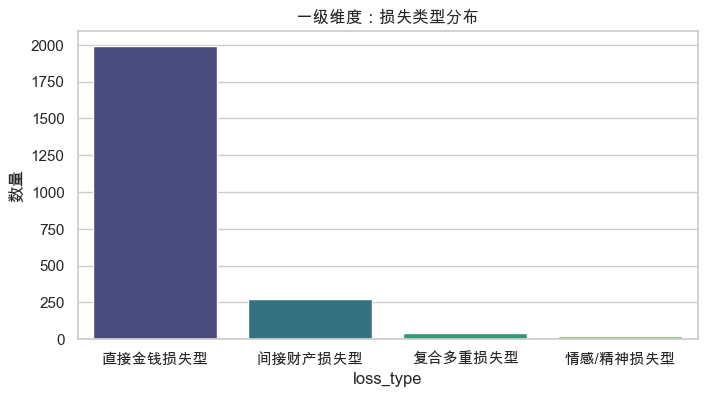

14:37:12 | INFO | 
[二级维度：危害等级分布 统计表]
            数量      占比(%)
severity                 
中度危害      2148  92.307692
轻度危害       124   5.328749
重度危害        51   2.191663
极端危害         4   0.171895


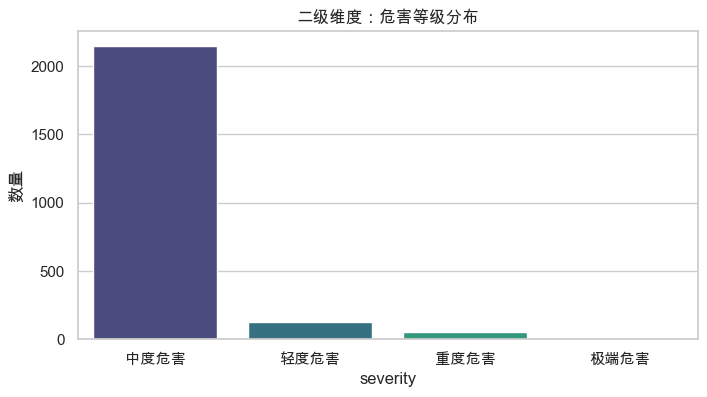

14:37:13 | INFO | 
[三级维度：时间周期分布 统计表]
             数量     占比(%)
time_span                
即时一次性损失    2269  97.50752
长期持续损失       58   2.49248


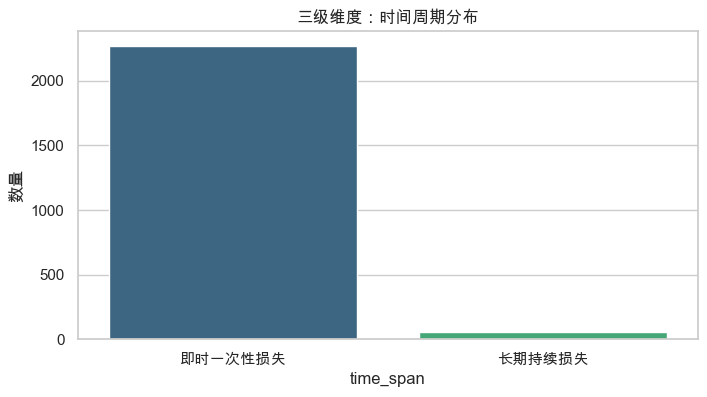

14:37:13 | INFO | 
--- 交叉统计：损失类型 ↔ 危害等级 ---
severity   中度危害  极端危害  轻度危害  重度危害
loss_type                        
复合多重损失型       9     3     0    31
情感/精神损失型      4     0    16     0
直接金钱损失型    1968     1    16     9
间接财产损失型     167     0    92    11
14:37:13 | INFO | 
--- Cluster Feature Profiles ---
14:37:13 | INFO | 
                       loss_type           severity                  time_span
cluster                                                                       
0          Direct Financial Loss  Moderate Severity      Instant One-time Loss
1         Compound Multiple Loss    Severe Severity  Long-term Continuous Loss
2        Indirect Financial Loss      Mild Severity      Instant One-time Loss
3        Indirect Financial Loss  Moderate Severity      Instant One-time Loss


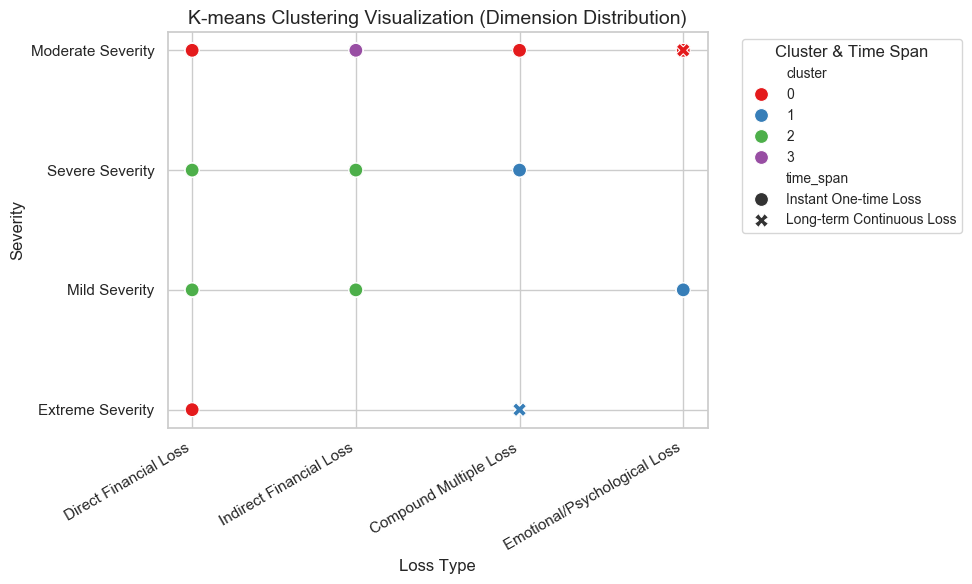

14:37:13 | INFO | 
--- 框架有效性验证 (卡方检验) ---
14:37:13 | INFO | loss_type vs severity: P值 = 0.0000 -> 显著相关 (有效)
14:37:13 | INFO | severity vs time_span: P值 = 0.0000 -> 显著相关 (有效)
14:37:13 | INFO | loss_type vs time_span: P值 = 0.0000 -> 显著相关 (有效)


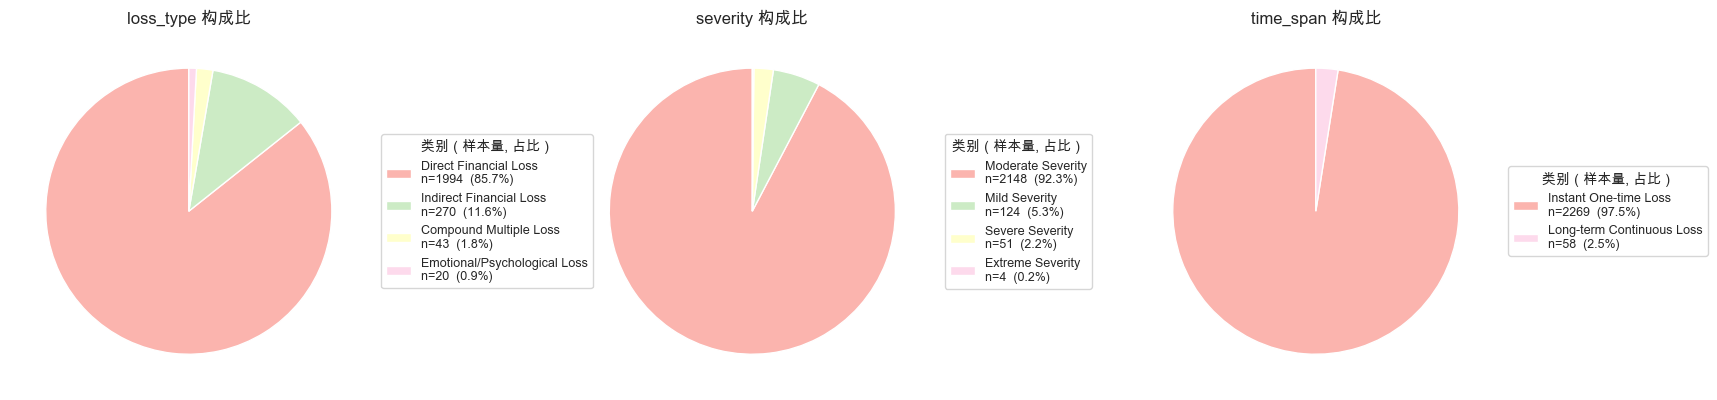

14:37:13 | INFO | 
[分析总结] 代码运行完毕。请根据 cluster_profile 结果填充类型学框架文档。


In [ ]:
import logging
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import chi2_contingency
from sklearn.cluster import KMeans
from sklearn.preprocessing import LabelEncoder

from src.utils import (
    DEFAULT_REQUIRED_LABEL_COLS as REQUIRED_COLS,
    align_series_for_label_encoding,
    first_mode,
    load_fraud_main_table,
    load_labeled_workbook,
    validate_labeled_columns,
    warn_post_id_alignment,
)

logger = logging.getLogger("fraud_analysis")

N_CLUSTERS = 4
df_main = load_fraud_main_table(PATHS)
df_labeled, xlsx_used = load_labeled_workbook(PATHS)
validate_labeled_columns(df_labeled, REQUIRED_COLS)

logger.info("--- 数据核对 ---")
logger.info("主数据样本数: %s", len(df_main))
logger.info("标签数据样本数: %s", len(df_labeled))
logger.info("标签文件: %s", xlsx_used)
if len(df_main) != len(df_labeled):
    logger.warning(
        "主数据与标签数据行数不一致 (csv=%s, xlsx=%s)，请确认是否按同一批样本标注。",
        len(df_main),
        len(df_labeled),
    )

warn_post_id_alignment(df_main, df_labeled, log=logger)

for col in REQUIRED_COLS:
    missing = df_labeled[col].isnull().sum()
    unique_vals = df_labeled[col].unique()
    logger.info("列 '%s': 缺失值 %s, 唯一标签: %s", col, missing, unique_vals)


def plot_stat(df: pd.DataFrame, column: str, title: str) -> None:
    counts = df[column].value_counts()
    percent = df[column].value_counts(normalize=True) * 100
    stat_df = pd.concat([counts, percent], axis=1, keys=["数量", "占比(%)"])
    logger.info("\n[%s 统计表]\n%s", title, stat_df)

    plot_df = counts.rename_axis(column).reset_index(name="数量")
    plt.figure(figsize=(8, 4))
    sns.barplot(
        data=plot_df,
        x=column,
        y="数量",
        hue=column,
        palette="viridis",
        legend=False,
    )
    plt.title(title)
    plt.ylabel("数量")
    plt.show()


def chi_square_pair(df: pd.DataFrame, c1: str, c2: str) -> None:
    table = pd.crosstab(df[c1], df[c2])
    if table.size == 0 or table.shape[0] < 2 or table.shape[1] < 2:
        logger.warning("%s vs %s: 列联表维度不足，跳过卡方检验", c1, c2)
        return
    try:
        _chi2, p, _dof, _expected = chi2_contingency(table)
    except ValueError as exc:
        logger.warning("%s vs %s: 卡方检验无法计算 (%s)", c1, c2, exc)
        return
    result = "显著相关 (有效)" if p < 0.05 else "相关性不显著"
    logger.info("%s vs %s: P值 = %.4f -> %s", c1, c2, p, result)


plot_stat(df_labeled, "loss_type", "一级维度：损失类型分布")
plot_stat(df_labeled, "severity", "二级维度：危害等级分布")
plot_stat(df_labeled, "time_span", "三级维度：时间周期分布")

logger.info(
    "\n--- 交叉统计：损失类型 ↔ 危害等级 ---\n%s",
    pd.crosstab(df_labeled["loss_type"], df_labeled["severity"]),
)

le_dict: dict[str, LabelEncoder] = {}
cluster_df = df_labeled[list(REQUIRED_COLS)].copy()

for col in REQUIRED_COLS:
    le = LabelEncoder()
    cluster_df[col + "_idx"] = le.fit_transform(
        align_series_for_label_encoding(cluster_df[col], col, log=logger)
    )
    le_dict[col] = le

# 先定义维度的英文映射字典（替换所有中文标签）
loss_type_mapping = {
    "直接金钱损失型": "Direct Financial Loss",
    "间接财产损失型": "Indirect Financial Loss",
    "复合多重损失型": "Compound Multiple Loss",
    "情感/精神损失型": "Emotional/Psychological Loss"
}

severity_mapping = {
    "轻度危害": "Mild Severity",
    "中度危害": "Moderate Severity",
    "重度危害": "Severe Severity",
    "极端危害": "Extreme Severity"
}

time_span_mapping = {
    "即时一次性损失": "Instant One-time Loss",
    "长期持续损失": "Long-term Continuous Loss"
}

# 替换DataFrame中的中文值为英文
df_labeled["loss_type"] = df_labeled["loss_type"].map(loss_type_mapping)
df_labeled["severity"] = df_labeled["severity"].map(severity_mapping)
df_labeled["time_span"] = df_labeled["time_span"].map(time_span_mapping)

# K-means聚类
kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=RANDOM_STATE, n_init=10)
feature_cols = [c + "_idx" for c in REQUIRED_COLS]
df_labeled = df_labeled.copy()
df_labeled["cluster"] = kmeans.fit_predict(cluster_df[feature_cols])

# 英文日志输出
logger.info("\n--- Cluster Feature Profiles ---")
cluster_profile = df_labeled.groupby("cluster")[list(REQUIRED_COLS)].agg(first_mode)
logger.info("\n%s", cluster_profile)

# 纯英文可视化图表
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_labeled,
    x="loss_type",
    y="severity",
    hue="cluster",
    style="time_span",
    s=100,
    palette="Set1",
)
# 全英文标题、坐标轴、图例
plt.title("K-means Clustering Visualization (Dimension Distribution)", fontsize=14)
plt.xlabel("Loss Type", fontsize=12)
plt.ylabel("Severity", fontsize=12)
plt.xticks(rotation=30, ha="right")  # 旋转X轴标签避免重叠
plt.legend(
    bbox_to_anchor=(1.05, 1), 
    loc="upper left", 
    title="Cluster & Time Span",
    fontsize=10
)
plt.tight_layout()
plt.show()

logger.info("\n--- 框架有效性验证 (卡方检验) ---")
chi_square_pair(df_labeled, "loss_type", "severity")
chi_square_pair(df_labeled, "severity", "time_span")
chi_square_pair(df_labeled, "loss_type", "time_span")

import matplotlib as mpl

def plot_pie_composition(ax, series: pd.Series, title: str) -> None:
    """扇区内不写文字，比例与类别名全部放在右侧图例，避免小块标签重叠。"""
    vc = series.value_counts(dropna=False)
    n = len(vc)
    cmap = mpl.colormaps["Pastel1"]
    colors = cmap(np.linspace(0, 0.88, max(n, 2)))[:n]
    total = float(vc.sum())

    wedges, _t = ax.pie(
        vc.values,
        labels=None,
        autopct=None,
        startangle=90,
        colors=colors,
        wedgeprops={"linewidth": 1.0, "edgecolor": "white"},
    )
    legend_labels = [
        f"{lab}\nn={c}  ({c / total * 100:.1f}%)"
        for lab, c in zip(vc.index.astype(str), vc.values)
    ]
    ax.legend(
        wedges,
        legend_labels,
        title="类别（样本量, 占比）",
        loc="center left",
        bbox_to_anchor=(1.02, 0.5),
        fontsize=9,
        title_fontsize=10,
    )
    ax.set_title(title, fontsize=12)
    ax.set_ylabel("")


fig, axes = plt.subplots(1, 3, figsize=(22, 6))
for ax, col in zip(axes, REQUIRED_COLS):
    plot_pie_composition(ax, df_labeled[col], f"{col} 构成比")
fig.tight_layout(rect=[0, 0, 0.78, 1])
plt.show()

logger.info(
    "\n[分析总结] 代码运行完毕。请根据 cluster_profile 结果填充类型学框架文档。"
)
